In [1]:
from utils import calc_r_squared, build_expression
from ponto2D import ListaPontos2D
from minimos_quadrados import get_coeficientes
from non_linear import growth_regression, exponencial_regression, potencia_regression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
x_values = [1,2,3,4,5,6,7,8]
y_values = [0.2,1.1,3.0,6.2,11.1,17.2,25.1,34]
pontos = ListaPontos2D.from_x_y_values(x_values, y_values)
pontos.print()

(1, 0.2)
(2, 1.1)
(3, 3.0)
(4, 6.2)
(5, 11.1)
(6, 17.2)
(7, 25.1)
(8, 34)


In [3]:
ajustes = {
    'Reta': {'coeficientes': get_coeficientes(pontos, grau=1)},
    'Potencia': {'coeficientes': potencia_regression(pontos)},
    'Exponencial': {'coeficientes': exponencial_regression(pontos)},
    'Saturacao': {'coeficientes': growth_regression(pontos)},
    'Parabola': {'coeficientes': get_coeficientes(pontos, grau=2)},
}

for key, value in ajustes.items():
    ajustes[key]['expressao'] = build_expression(key.lower(), value['coeficientes'])

In [4]:
def plot_ajustes(x_values, y_values, ajustes):
    plt.figure(figsize=(10, 6))
    plt.scatter(x_values, y_values, color='red', label='Dados Originais')

    x_range = np.linspace(min(x_values), max(x_values), 1000)

    for ajuste, info in ajustes.items():
        expressao = info['expressao']
        y_fit = [expressao.subs({'x': x}) for x in x_range]
        r_squared = calc_r_squared(pontos, info['expressao'])
        plt.plot(x_range, y_fit, label=f'{ajuste} (R²={r_squared:.4f})')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Ajustes de Curvas')
    plt.legend()
    plt.show()

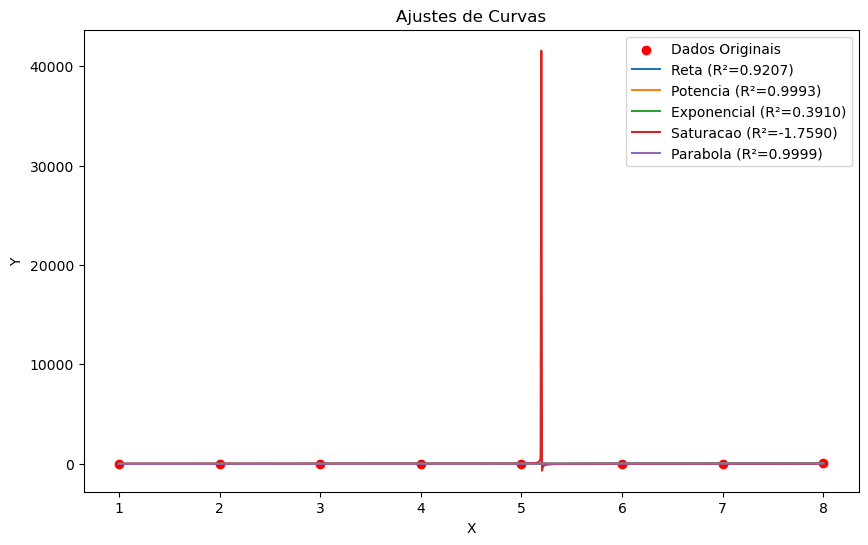

In [7]:
plot_ajustes(x_values, y_values, ajustes)

In [6]:
for ajuste, coeficientes in ajustes.items():
    print(f"{ajuste} coeficientes: {coeficientes['coeficientes']}")
    print(f"{ajuste} expressão: {coeficientes['expressao']}")
    r_squared = calc_r_squared(pontos, coeficientes['expressao'])
    print(f"{ajuste} R²: {r_squared}\n")

Reta coeficientes: [-9.410714285714285, 4.810714285714286]
Reta expressão: 4.81071428571429*x - 9.41071428571428
Reta R²: 0.9207217697554074

Potencia coeficientes: [0.198691683142108, 2.4836502456317207]
Potencia expressão: 0.198691683142108*x**2.48365024563172
Potencia R²: 0.9993159280942238

Exponencial coeficientes: [0.24678120322864047, 0.6834483868183339]
Exponencial expressão: 0.24678120322864*exp(0.683448386818334*x)
Exponencial R²: 0.39104374349518006

Saturacao coeficientes: [-0.9251430599149503, -5.197312931869756]
Saturacao expressão: -0.92514305991495*x/(x - 5.19731293186976)
Saturacao R²: -1.7589949835027034

Parabola coeficientes: [1.1696428571429276, -1.537500000000035, 0.7053571428571463]
Parabola expressão: 0.705357142857146*x**2 - 1.53750000000003*x + 1.16964285714293
Parabola R²: 0.9998966493586764



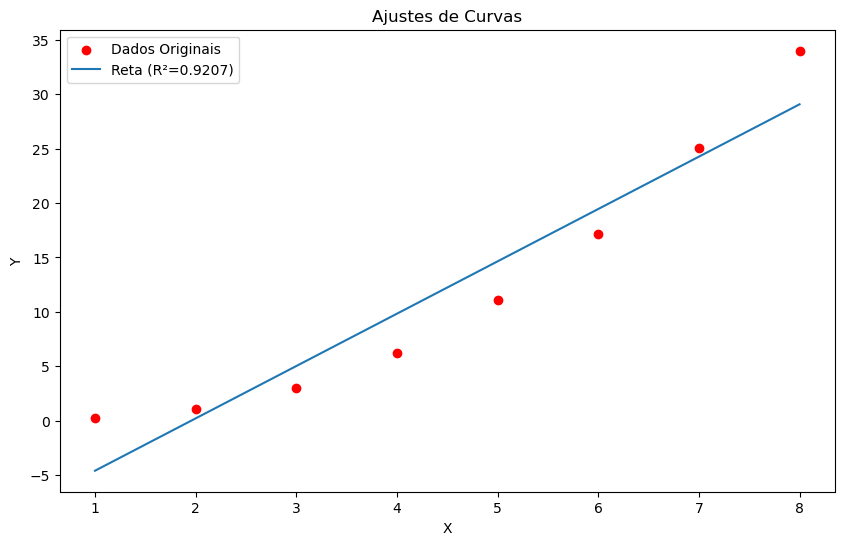

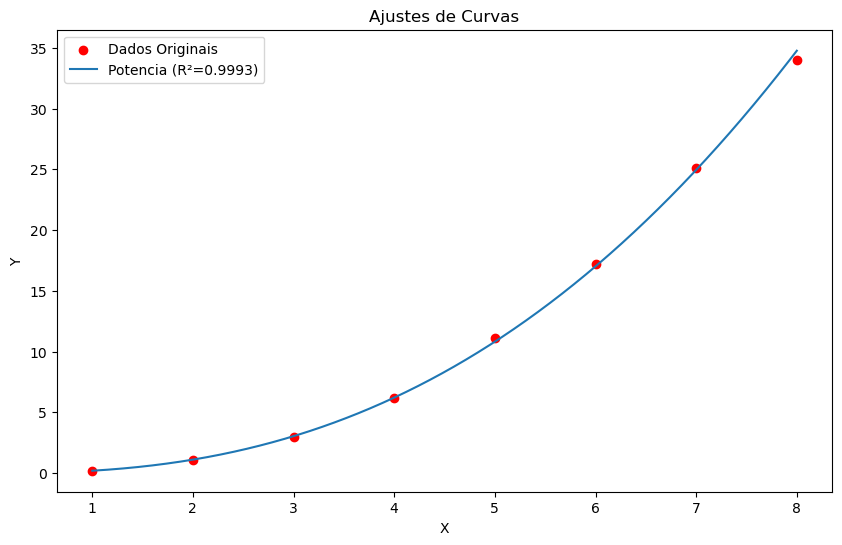

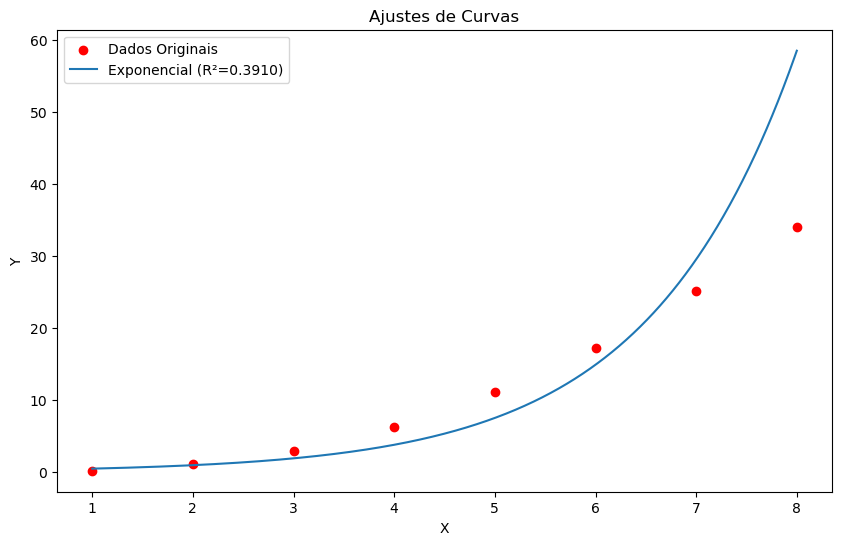

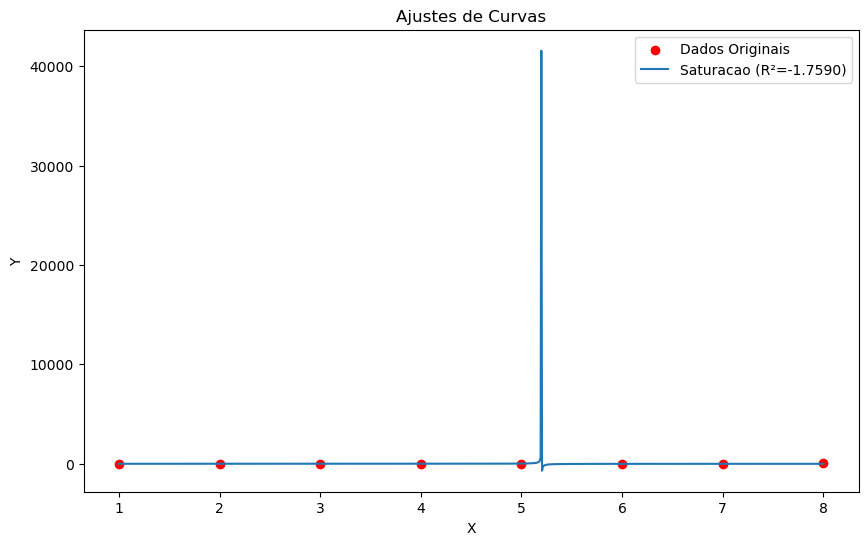

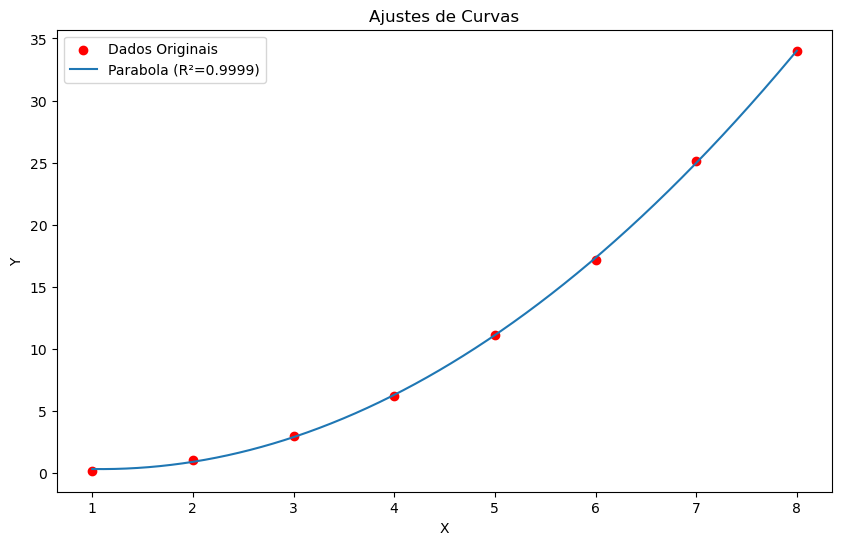

In [8]:
for ajuste, coeficientes in ajustes.items():
    plot_ajustes(x_values, y_values, {ajuste: coeficientes})

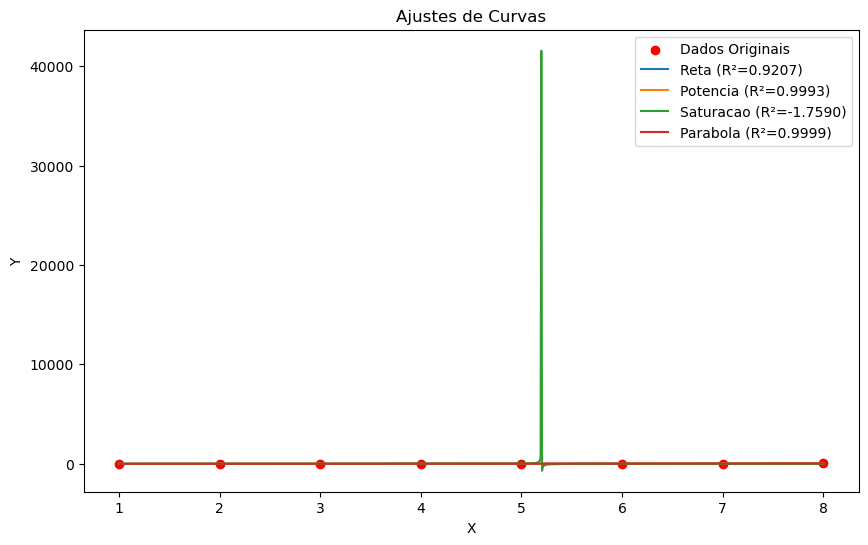

In [9]:
ajustes.pop('Exponencial')
plot_ajustes(x_values, y_values, ajustes)